# Project Objective – Weather Analytics Temperature Forecaster

## Project Objective
The objective of the Weather Analytics Temperature Forecaster project is to analyze historical weather data, identify patterns and relationships among weather features, and build a machine learning model to accurately predict temperature. The project aims to perform data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation to develop a reliable temperature forecasting system that can support weather analysis and prediction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/sample_weather_data.csv")

## Data Quality Audit and Feature Selection

In [3]:
# ============================================
# STEP 1: DATA QUALITY AUDIT
# ============================================

# Create a working copy
weather_df = df.copy()

print("Dataset Shape:")
print(weather_df.shape)

print("\nNumber of Duplicate Rows:")
print(weather_df.duplicated().sum())

print("\nMissing Values:")
missing_values = weather_df.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

print("\nNumber of Unique Values:")
print(weather_df.nunique().sort_values(ascending=False))

print("\nData Types:")
print(weather_df.dtypes)

print("\nDate Range:")
print("Minimum:", weather_df['last_updated'].min())
print("Maximum:", weather_df['last_updated'].max())

Dataset Shape:
(5000, 45)

Number of Duplicate Rows:
0

Missing Values:
Series([], dtype: int64)

Number of Unique Values:
last_updated                    3891
air_quality_PM10                1721
air_quality_Carbon_Monoxide     1455
moonset                         1392
moonrise                        1383
air_quality_PM2.5               1349
air_quality_Nitrogen_dioxide    1076
last_updated_epoch              1050
feels_like_fahrenheit            917
air_quality_Sulphur_dioxide      894
temperature_fahrenheit           669
feels_like_celsius               572
gust_kph                         510
temperature_celsius              457
sunset                           405
air_quality_Ozone                387
longitude                        366
latitude                         363
wind_degree                      360
gust_mph                         345
sunrise                          319
location_name                    217
precip_mm                        207
timezone                  

In [4]:
# ============================================
# TARGET VARIABLE ANALYSIS
# ============================================

target = 'temperature_celsius'

print("Target Variable:", target)

print("\nTarget Statistics:")
print(weather_df[target].describe())

print("\nNumber of Missing Target Values:")
print(weather_df[target].isnull().sum())

print("\nNumber of Unique Target Values:")
print(weather_df[target].nunique())

Target Variable: temperature_celsius

Target Statistics:
count    5000.000000
mean       20.966960
std         9.549961
min       -24.200000
25%        15.200000
50%        23.300000
75%        27.800000
max        46.700000
Name: temperature_celsius, dtype: float64

Number of Missing Target Values:
0

Number of Unique Target Values:
457


In [5]:
# ============================================
# CHECK FOR POTENTIAL DATA LEAKAGE
# ============================================

leakage_columns = [
    'temperature_fahrenheit',
    'feels_like_celsius',
    'feels_like_fahrenheit'
]

print("Potential Leakage Columns:")

for column in leakage_columns:
    if column in weather_df.columns:
        print(f"- {column}")

Potential Leakage Columns:
- temperature_fahrenheit
- feels_like_celsius
- feels_like_fahrenheit


In [6]:
# ============================================
# INITIAL FEATURE SELECTION
# ============================================

target = 'temperature_celsius'

features = [
    'humidity',
    'wind_kph',
    'wind_degree',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'gust_kph',
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index',
    'moon_illumination'
]

print("Number of selected features:", len(features))

print("\nSelected Features:")
for feature in features:
    print("-", feature)

Number of selected features: 18

Selected Features:
- humidity
- wind_kph
- wind_degree
- pressure_mb
- precip_mm
- cloud
- visibility_km
- uv_index
- gust_kph
- air_quality_Carbon_Monoxide
- air_quality_Ozone
- air_quality_Nitrogen_dioxide
- air_quality_Sulphur_dioxide
- air_quality_PM2.5
- air_quality_PM10
- air_quality_us-epa-index
- air_quality_gb-defra-index
- moon_illumination


In [7]:
# ============================================
# STEP 1 SUMMARY
# ============================================

print("=" * 60)
print("STEP 1: DATA QUALITY AUDIT SUMMARY")
print("=" * 60)

# 1. Dataset Shape
print("\n1. DATASET SHAPE")
print(weather_df.shape)

# 2. Duplicate Rows
print("\n2. DUPLICATE ROWS")
print(weather_df.duplicated().sum())

# 3. Missing Values
print("\n3. MISSING VALUES")
missing_values = weather_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found.")
else:
    print(missing_values.sort_values(ascending=False))

# 4. Date Range
print("\n4. DATE RANGE")
print("Minimum:", weather_df['last_updated'].min())
print("Maximum:", weather_df['last_updated'].max())

# 5. Target Statistics
print("\n5. TARGET STATISTICS")
print(weather_df['temperature_celsius'].describe())

# 6. Number of Selected Features
print("\n6. NUMBER OF SELECTED FEATURES")
print(len(features))

print("\nSelected Features:")
for feature in features:
    print("-", feature)

print("\n" + "=" * 60)
print("AUDIT COMPLETED")
print("=" * 60)

STEP 1: DATA QUALITY AUDIT SUMMARY

1. DATASET SHAPE
(5000, 45)

2. DUPLICATE ROWS
0

3. MISSING VALUES
No missing values found.

4. DATE RANGE
Minimum: 2024-05-16 03:45:00
Maximum: 2026-05-22 18:30:00

5. TARGET STATISTICS
count    5000.000000
mean       20.966960
std         9.549961
min       -24.200000
25%        15.200000
50%        23.300000
75%        27.800000
max        46.700000
Name: temperature_celsius, dtype: float64

6. NUMBER OF SELECTED FEATURES
18

Selected Features:
- humidity
- wind_kph
- wind_degree
- pressure_mb
- precip_mm
- cloud
- visibility_km
- uv_index
- gust_kph
- air_quality_Carbon_Monoxide
- air_quality_Ozone
- air_quality_Nitrogen_dioxide
- air_quality_Sulphur_dioxide
- air_quality_PM2.5
- air_quality_PM10
- air_quality_us-epa-index
- air_quality_gb-defra-index
- moon_illumination

AUDIT COMPLETED


## Temporal and Geographic Data Analysis

In [8]:
# ============================================
# STEP 2: TEMPORAL & GEOGRAPHIC DATA ANALYSIS
# ============================================

# Make sure last_updated is datetime
weather_df['last_updated'] = pd.to_datetime(
    weather_df['last_updated'],
    errors='coerce'
)

# --------------------------------------------
# 1. Number of unique locations
# --------------------------------------------

print("=" * 60)
print("GEOGRAPHIC ANALYSIS")
print("=" * 60)

print("\nNumber of Unique Countries:")
print(weather_df['country'].nunique())

print("\nNumber of Unique Locations:")
print(weather_df['location_name'].nunique())

print("\nTop 10 Countries by Number of Records:")
print(weather_df['country'].value_counts().head(10))

print("\nTop 10 Locations by Number of Records:")
print(weather_df['location_name'].value_counts().head(10))


# --------------------------------------------
# 2. Records per location
# --------------------------------------------

records_per_location = (
    weather_df
    .groupby(['country', 'location_name'])
    .size()
    .sort_values(ascending=False)
)

print("\nRecords per Location - Statistics:")
print(records_per_location.describe())

print("\nTop 10 Locations by Number of Records:")
print(records_per_location.head(10))


# --------------------------------------------
# 3. Temporal coverage
# --------------------------------------------

print("\n" + "=" * 60)
print("TEMPORAL ANALYSIS")
print("=" * 60)

print("\nMinimum Date:")
print(weather_df['last_updated'].min())

print("\nMaximum Date:")
print(weather_df['last_updated'].max())

print("\nNumber of Unique Dates:")
print(weather_df['last_updated'].dt.date.nunique())

print("\nNumber of Unique Months:")
print(weather_df['last_updated'].dt.to_period('M').nunique())


# --------------------------------------------
# 4. Records per date
# --------------------------------------------

records_per_date = (
    weather_df['last_updated']
    .dt.date
    .value_counts()
    .sort_index()
)

print("\nRecords per Date - Statistics:")
print(records_per_date.describe())

print("\nFirst 10 Dates:")
print(records_per_date.head(10))

print("\nLast 10 Dates:")
print(records_per_date.tail(10))


# --------------------------------------------
# 5. Check records per location over time
# --------------------------------------------

location_date_counts = (
    weather_df
    .groupby(['location_name', weather_df['last_updated'].dt.date])
    .size()
)

print("\nRecords per Location-Date - Statistics:")
print(location_date_counts.describe())


# --------------------------------------------
# 6. Sample location history
# --------------------------------------------

sample_location = weather_df['location_name'].value_counts().index[0]

print("\nSample Location:")
print(sample_location)

sample_data = (
    weather_df[
        weather_df['location_name'] == sample_location
    ]
    [['country', 'location_name', 'last_updated', 'temperature_celsius']]
    .sort_values('last_updated')
)

print("\nSample Location Date Range:")
print("Minimum:", sample_data['last_updated'].min())
print("Maximum:", sample_data['last_updated'].max())

print("\nSample Location Records:")
print(sample_data.head(10))

GEOGRAPHIC ANALYSIS

Number of Unique Countries:
186

Number of Unique Locations:
217

Top 10 Countries by Number of Records:
country
Bolivia                   58
Bulgaria                  54
Turkey                    51
Belgium                   48
Thailand                  46
Iran                      46
Madagascar                42
Vietnam                   41
Indonesia                 39
Bosnia and Herzegovina    39
Name: count, dtype: int64

Top 10 Locations by Number of Records:
location_name
Sarajevo        39
Wellington      37
Porto-Novo      37
Tunis           37
Roseau          36
Tegucigalpa     36
Vatican City    34
Madrid          34
Moscow          34
Bern            34
Name: count, dtype: int64

Records per Location - Statistics:
count    219.000000
mean      22.831050
std        8.306278
min        1.000000
25%       20.000000
50%       24.000000
75%       28.000000
max       39.000000
dtype: float64

Top 10 Locations by Number of Records:
country                 locat

## Feature Engineering

In [9]:
# ============================================
# STEP 2: FEATURE ENGINEERING
# ============================================

# Create a copy
weather_df = weather_df.copy()

# --------------------------------------------
# 1. Convert datetime
# --------------------------------------------

weather_df['last_updated'] = pd.to_datetime(
    weather_df['last_updated'],
    errors='coerce'
)

# --------------------------------------------
# 2. Create unique location identifier
# --------------------------------------------

weather_df['location_id'] = (
    weather_df['country'].astype(str)
    + "_"
    + weather_df['location_name'].astype(str)
)

# --------------------------------------------
# 3. Extract temporal features
# --------------------------------------------

weather_df['year'] = weather_df['last_updated'].dt.year

weather_df['month'] = weather_df['last_updated'].dt.month

weather_df['day'] = weather_df['last_updated'].dt.day

weather_df['hour'] = weather_df['last_updated'].dt.hour

weather_df['day_of_year'] = (
    weather_df['last_updated'].dt.dayofyear
)

weather_df['day_of_week'] = (
    weather_df['last_updated'].dt.dayofweek
)

# --------------------------------------------
# 4. Create season
# --------------------------------------------

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

weather_df['season'] = (
    weather_df['month'].apply(get_season)
)

# --------------------------------------------
# 5. Cyclical encoding
# --------------------------------------------

# Month cyclical encoding
weather_df['month_sin'] = np.sin(
    2 * np.pi * weather_df['month'] / 12
)

weather_df['month_cos'] = np.cos(
    2 * np.pi * weather_df['month'] / 12
)

# Hour cyclical encoding
weather_df['hour_sin'] = np.sin(
    2 * np.pi * weather_df['hour'] / 24
)

weather_df['hour_cos'] = np.cos(
    2 * np.pi * weather_df['hour'] / 24
)

# --------------------------------------------
# 6. Display new features
# --------------------------------------------

print("New dataset shape:")
print(weather_df.shape)

print("\nNew features created:")

new_features = [
    'location_id',
    'year',
    'month',
    'day',
    'hour',
    'day_of_year',
    'day_of_week',
    'season',
    'month_sin',
    'month_cos',
    'hour_sin',
    'hour_cos'
]

for feature in new_features:
    print("-", feature)

New dataset shape:
(5000, 54)

New features created:
- location_id
- year
- month
- day
- hour
- day_of_year
- day_of_week
- season
- month_sin
- month_cos
- hour_sin
- hour_cos


In [10]:
# ============================================
# CHECK ENGINEERED FEATURES
# ============================================

print(weather_df[
    [
        'country',
        'location_name',
        'location_id',
        'last_updated',
        'temperature_celsius',
        'latitude',
        'longitude',
        'year',
        'month',
        'day',
        'hour',
        'season',
        'month_sin',
        'month_cos',
        'hour_sin',
        'hour_cos'
    ]
].head(10))

                    country   location_name                       location_id  \
0       Antigua and Barbuda    Saint John's  Antigua and Barbuda_Saint John's   
1                Kazakhstan          Astana                 Kazakhstan_Astana   
2                   Vietnam         Ban Lom                   Vietnam_Ban Lom   
3                  Bulgaria             Lom                      Bulgaria_Lom   
4                Cape Verde           Praia                  Cape Verde_Praia   
5                  Cambodia      Phnom Penh               Cambodia_Phnom Penh   
6                    Brazil            Bras                       Brazil_Bras   
7                   Romania       Bucharest                 Romania_Bucharest   
8  Central African Republic          Bangui   Central African Republic_Bangui   
9                 Guatemala  Guatemala City          Guatemala_Guatemala City   

         last_updated  temperature_celsius  latitude  longitude  year  month  \
0 2024-07-03 09:00:00       

In [11]:
print(weather_df.shape)

print("\nSeason Distribution:")
print(weather_df['season'].value_counts())

print("\nYear Distribution:")
print(weather_df['year'].value_counts().sort_index())

print("\nMonth Distribution:")
print(weather_df['month'].value_counts().sort_index())

(5000, 54)

Season Distribution:
season
Winter    1312
Summer    1244
Spring    1241
Autumn    1203
Name: count, dtype: int64

Year Distribution:
year
2024    1583
2025    2476
2026     941
Name: count, dtype: int64

Month Distribution:
month
1     450
2     414
3     391
4     388
5     462
6     407
7     413
8     424
9     391
10    389
11    423
12    448
Name: count, dtype: int64


## Preparing the Machine Learning Dataset

In [12]:
# ============================================
# STEP 3: FINAL FEATURE SELECTION
# ============================================

target = 'temperature_celsius'

# --------------------------------------------
# 1. Target leakage columns
# --------------------------------------------

leakage_columns = [
    'temperature_fahrenheit',
    'feels_like_celsius',
    'feels_like_fahrenheit'
]

# --------------------------------------------
# 2. Redundant unit columns
# --------------------------------------------

redundant_unit_columns = [
    'wind_mph',
    'pressure_in',
    'precip_in',
    'visibility_miles',
    'gust_mph'
]

# --------------------------------------------
# 3. Raw identifiers / text columns
# --------------------------------------------

identifier_columns = [
    'country',
    'location_name',
    'location_id',
    'timezone',
    'last_updated',
    'condition_text',
    'wind_direction',
    'sunrise',
    'sunset',
    'moonrise',
    'moonset',
    'moon_phase'
]

# --------------------------------------------
# 4. Remove features that should not be used
# --------------------------------------------

columns_to_exclude = (
    leakage_columns
    + redundant_unit_columns
    + identifier_columns
    + [
        target,
        'last_updated_epoch',
        'anomaly'
    ]
)

# --------------------------------------------
# 5. Create final model feature list
# --------------------------------------------

model_features = [
    column
    for column in weather_df.columns
    if column not in columns_to_exclude
]

# --------------------------------------------
# 6. Create X and y
# --------------------------------------------

X = weather_df[model_features].copy()

y = weather_df[target].copy()

# --------------------------------------------
# 7. Display final results
# --------------------------------------------

print("=" * 60)
print("FINAL MODEL DATASET")
print("=" * 60)

print("\nTarget Variable:")
print(target)

print("\nNumber of Model Features:")
print(len(model_features))

print("\nModel Features:")
for feature in model_features:
    print("-", feature)

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

FINAL MODEL DATASET

Target Variable:
temperature_celsius

Number of Model Features:
31

Model Features:
- latitude
- longitude
- wind_kph
- wind_degree
- pressure_mb
- precip_mm
- humidity
- cloud
- visibility_km
- uv_index
- gust_kph
- air_quality_Carbon_Monoxide
- air_quality_Ozone
- air_quality_Nitrogen_dioxide
- air_quality_Sulphur_dioxide
- air_quality_PM2.5
- air_quality_PM10
- air_quality_us-epa-index
- air_quality_gb-defra-index
- moon_illumination
- year
- month
- day
- hour
- day_of_year
- day_of_week
- season
- month_sin
- month_cos
- hour_sin
- hour_cos

X Shape:
(5000, 31)

y Shape:
(5000,)


In [13]:
# ============================================
# FINAL FEATURE TYPE CHECK
# ============================================

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:")
print(len(numerical_features))

print("\nNumber of Categorical Features:")
print(len(categorical_features))

Numerical Features:
['latitude', 'longitude', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination', 'year', 'month', 'day', 'hour', 'day_of_year', 'day_of_week', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

Categorical Features:
['season']

Number of Numerical Features:
30

Number of Categorical Features:
1


In [14]:
# ============================================
# FINAL LEAKAGE CHECK
# ============================================

suspicious_features = [
    'temperature_celsius',
    'temperature_fahrenheit',
    'feels_like_celsius',
    'feels_like_fahrenheit',
    'anomaly'
]

print("Leakage Check:")
print("=" * 40)

for feature in suspicious_features:
    if feature in X.columns:
        print(f"⚠️ FOUND: {feature}")
    else:
        print(f"✅ REMOVED: {feature}")

Leakage Check:
✅ REMOVED: temperature_celsius
✅ REMOVED: temperature_fahrenheit
✅ REMOVED: feels_like_celsius
✅ REMOVED: feels_like_fahrenheit
✅ REMOVED: anomaly


In [15]:
# ============================================
# FEATURE-TARGET CORRELATION
# ============================================

correlation_with_target = (
    weather_df[
        X.select_dtypes(include=np.number).columns.tolist()
        + [target]
    ]
    .corr()[target]
    .sort_values(ascending=False)
)

print("Correlation with Temperature:")
print(correlation_with_target)

Correlation with Temperature:
temperature_celsius             1.000000
uv_index                        0.485629
air_quality_Ozone               0.267882
hour                            0.206592
visibility_km                   0.134764
longitude                       0.106709
wind_kph                        0.104104
air_quality_PM10                0.090537
month                           0.088817
day_of_year                     0.088429
gust_kph                        0.077644
air_quality_gb-defra-index      0.068100
air_quality_us-epa-index        0.059037
precip_mm                       0.056811
air_quality_PM2.5               0.047699
hour_cos                        0.019972
day                             0.009920
moon_illumination               0.008985
air_quality_Carbon_Monoxide     0.000149
day_of_week                    -0.006763
wind_degree                    -0.015617
air_quality_Sulphur_dioxide    -0.071337
cloud                          -0.133372
air_quality_Nitrogen_dioxid

In [16]:
# ============================================
# CHECK FOR POTENTIAL LEAKAGE
# ============================================

print("\nPotentially Suspicious Correlations:")

for feature, correlation in correlation_with_target.items():
    if feature != target and abs(correlation) > 0.80:
        print(
            f"{feature}: {correlation:.4f}"
        )


Potentially Suspicious Correlations:


## Train-Test Split Strategy

In [17]:
# ============================================
# STEP 4: TIME-BASED TRAIN-TEST SPLIT
# ============================================

# Create a copy of the modeling data
model_df = weather_df[model_features + [target]].copy()

# --------------------------------------------
# Sort data chronologically
# --------------------------------------------

model_df = model_df.sort_index()

# --------------------------------------------
# Time-based split
# --------------------------------------------

train_df = model_df[
    model_df['year'] < 2026
].copy()

test_df = model_df[
    model_df['year'] == 2026
].copy()

# --------------------------------------------
# Separate features and target
# --------------------------------------------

X_train_time = train_df[model_features].copy()
y_train_time = train_df[target].copy()

X_test_time = test_df[model_features].copy()
y_test_time = test_df[target].copy()

# --------------------------------------------
# Display split information
# --------------------------------------------

print("=" * 60)
print("TIME-BASED TRAIN-TEST SPLIT")
print("=" * 60)

print("\nTraining Data:")
print("Shape:", X_train_time.shape)

print("\nTesting Data:")
print("Shape:", X_test_time.shape)

print("\nTraining Years:")
print(sorted(train_df['year'].unique()))

print("\nTesting Years:")
print(sorted(test_df['year'].unique()))

print("\nTraining Target Statistics:")
print(y_train_time.describe())

print("\nTesting Target Statistics:")
print(y_test_time.describe())

TIME-BASED TRAIN-TEST SPLIT

Training Data:
Shape: (4059, 31)

Testing Data:
Shape: (941, 31)

Training Years:
[2024, 2025]

Testing Years:
[2026]

Training Target Statistics:
count    4059.000000
mean       21.826361
std         9.132032
min       -24.200000
25%        16.400000
50%        24.200000
75%        28.100000
max        46.700000
Name: temperature_celsius, dtype: float64

Testing Target Statistics:
count    941.000000
mean      17.259936
std       10.395147
min      -19.700000
25%       10.200000
50%       19.200000
75%       25.300000
max       37.300000
Name: temperature_celsius, dtype: float64


In [18]:
# ============================================
# RANDOM TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train_random, X_test_random, y_train_random, y_test_random = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

print("=" * 60)
print("RANDOM TRAIN-TEST SPLIT")
print("=" * 60)

print("\nTraining Data:")
print(X_train_random.shape)

print("\nTesting Data:")
print(X_test_random.shape)

RANDOM TRAIN-TEST SPLIT

Training Data:
(4000, 31)

Testing Data:
(1000, 31)


In [19]:
# ============================================
# COMPARE SPLIT STRATEGIES
# ============================================

print("=" * 60)
print("SPLIT STRATEGY COMPARISON")
print("=" * 60)

print("\nRandom Split:")
print("Train:", X_train_random.shape[0])
print("Test :", X_test_random.shape[0])

print("\nTime-Based Split:")
print("Train:", X_train_time.shape[0])
print("Test :", X_test_time.shape[0])

SPLIT STRATEGY COMPARISON

Random Split:
Train: 4000
Test : 1000

Time-Based Split:
Train: 4059
Test : 941


## Machine Learning Pipeline

In [20]:
# ============================================
# STEP 5: MACHINE LEARNING PREPROCESSING
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical features
numerical_features = X_train_time.select_dtypes(
    include=np.number
).columns.tolist()

# Identify categorical features
categorical_features = X_train_time.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nNumber of Numerical Features:",
      len(numerical_features))

print("Number of Categorical Features:",
      len(categorical_features))

Numerical Features:
['latitude', 'longitude', 'wind_kph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'moon_illumination', 'year', 'month', 'day', 'hour', 'day_of_year', 'day_of_week', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

Categorical Features:
['season']

Number of Numerical Features: 30
Number of Categorical Features: 1


In [21]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
# ============================================
# LINEAR REGRESSION BASELINE
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_regression_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            LinearRegression()
        )
    ]
)

print("Linear Regression pipeline created.")

Linear Regression pipeline created.


In [23]:
# ============================================
# TRAIN LINEAR REGRESSION
# ============================================

linear_regression_pipeline.fit(
    X_train_time,
    y_train_time
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [24]:
# ============================================
# LINEAR REGRESSION PREDICTIONS
# ============================================

y_pred_lr = linear_regression_pipeline.predict(
    X_test_time
)

print("Predictions generated successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_lr[:10])

Predictions generated successfully.

First 10 Predictions:
[19.72105214 20.12218807 13.69172082 20.44585282 23.80778883 12.84795339
 12.87875914  1.92690554 19.54716962 19.28079931]


In [25]:
# ============================================
# LINEAR REGRESSION EVALUATION
# ============================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(
    y_test_time,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test_time,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test_time,
    y_pred_lr
)

print("=" * 60)
print("LINEAR REGRESSION - TIME-BASED EVALUATION")
print("=" * 60)

print(f"\nMAE  : {mae_lr:.4f} °C")
print(f"RMSE : {rmse_lr:.4f} °C")
print(f"R²   : {r2_lr:.4f}")

LINEAR REGRESSION - TIME-BASED EVALUATION

MAE  : 5.7460 °C
RMSE : 7.5607 °C
R²   : 0.4704


## Random Forest Regression

In [26]:
# ============================================
# STEP 6: RANDOM FOREST REGRESSION
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [27]:
# ============================================
# TRAIN RANDOM FOREST
# ============================================

random_forest_pipeline.fit(
    X_train_time,
    y_train_time
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [28]:
# ============================================
# RANDOM FOREST PREDICTIONS
# ============================================

y_pred_rf = random_forest_pipeline.predict(
    X_test_time
)

print("Predictions generated successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_rf[:10])

Predictions generated successfully.

First 10 Predictions:
[ 5.5735 22.3685  3.974  18.608  29.563   4.572   3.1645  0.039  10.9725
 24.5245]


In [29]:
# ============================================
# RANDOM FOREST EVALUATION
# ============================================

mae_rf = mean_absolute_error(
    y_test_time,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_time,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test_time,
    y_pred_rf
)

print("=" * 60)
print("RANDOM FOREST - TIME-BASED EVALUATION")
print("=" * 60)

print(f"\nMAE  : {mae_rf:.4f} °C")
print(f"RMSE : {rmse_rf:.4f} °C")
print(f"R²   : {r2_rf:.4f}")

RANDOM FOREST - TIME-BASED EVALUATION

MAE  : 3.0407 °C
RMSE : 4.2946 °C
R²   : 0.8291


## XGBoost Regression

In [30]:
# ============================================
# STEP 7: XGBOOST REGRESSION
# ============================================

from xgboost import XGBRegressor

# Create XGBoost pipeline
xgboost_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                objective='reg:squarederror',
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [31]:
# ============================================
# TRAIN XGBOOST
# ============================================

xgboost_pipeline.fit(
    X_train_time,
    y_train_time
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [32]:
# ============================================
# XGBOOST PREDICTIONS
# ============================================

y_pred_xgb = xgboost_pipeline.predict(
    X_test_time
)

print("Predictions generated successfully.")

print("\nFirst 10 Predictions:")
print(y_pred_xgb[:10])

Predictions generated successfully.

First 10 Predictions:
[ 4.425251   23.583748    4.9532123  19.393534   28.69621     4.5662255
  4.295963    0.47858867 10.5465975  25.372627  ]


In [33]:
# ============================================
# XGBOOST EVALUATION
# ============================================

mae_xgb = mean_absolute_error(
    y_test_time,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test_time,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test_time,
    y_pred_xgb
)

print("=" * 60)
print("XGBOOST - TIME-BASED EVALUATION")
print("=" * 60)

print(f"\nMAE  : {mae_xgb:.4f} °C")
print(f"RMSE : {rmse_xgb:.4f} °C")
print(f"R²   : {r2_xgb:.4f}")

XGBOOST - TIME-BASED EVALUATION

MAE  : 2.8695 °C
RMSE : 4.0648 °C
R²   : 0.8469


## Baseline Model Comparison

In [34]:
# ============================================
# STEP 8: MODEL COMPARISON
# ============================================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_xgb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_xgb
    ]
})

# Sort by R2 score
results = results.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

print(results)

               Model       MAE      RMSE        R2
0            XGBoost  2.869500  4.064776  0.846936
1      Random Forest  3.040700  4.294647  0.829134
2  Linear Regression  5.746025  7.560663  0.470434


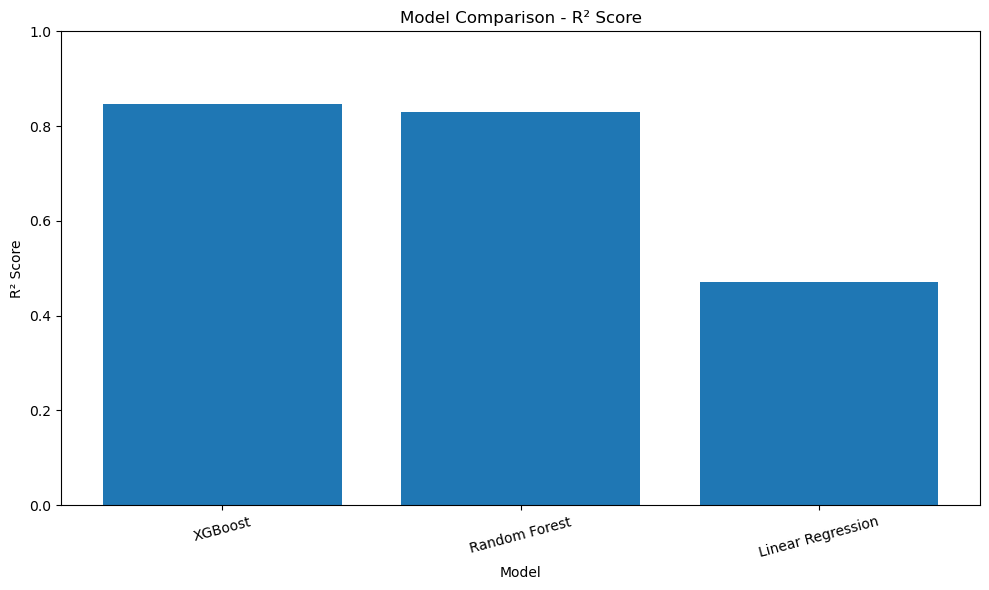

In [35]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results['Model'],
    results['R2']
)

plt.title(
    'Model Comparison - R² Score'
)

plt.xlabel('Model')

plt.ylabel('R² Score')

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [36]:
# ============================================
# STEP 9: PREPARE DATA FOR HYPERPARAMETER TUNING
# ============================================

from sklearn.model_selection import RandomizedSearchCV

# Create XGBoost pipeline for tuning
xgb_tuning_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            XGBRegressor(
                objective='reg:squarederror',
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost tuning pipeline created successfully.")

XGBoost tuning pipeline created successfully.


In [37]:
# ============================================
# XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================

param_distributions = {
    'model__n_estimators': [
        200,
        300,
        500,
        700
    ],
    
    'model__learning_rate': [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    
    'model__max_depth': [
        3,
        4,
        5,
        6,
        8
    ],
    
    'model__min_child_weight': [
        1,
        3,
        5
    ],
    
    'model__subsample': [
        0.7,
        0.8,
        0.9,
        1.0
    ],
    
    'model__colsample_bytree': [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


In [38]:
# ============================================
# RANDOMIZED SEARCH
# ============================================

random_search = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting XGBoost hyperparameter tuning...")

random_search.fit(
    X_train_time,
    y_train_time
)

print("Hyperparameter tuning completed.")

Starting XGBoost hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter tuning completed.


In [39]:
# ============================================
# BEST XGBOOST PARAMETERS
# ============================================

print("=" * 60)
print("BEST XGBOOST PARAMETERS")
print("=" * 60)

print("\nBest Parameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest Cross-Validation MAE:")
print(
    f"{-random_search.best_score_:.4f} °C"
)

BEST XGBOOST PARAMETERS

Best Parameters:
model__subsample: 0.7
model__n_estimators: 700
model__min_child_weight: 5
model__max_depth: 5
model__learning_rate: 0.1
model__colsample_bytree: 0.7

Best Cross-Validation MAE:
1.9813 °C


In [40]:
# ============================================
# EVALUATE TUNED XGBOOST ON 2026
# ============================================

best_xgb_model = random_search.best_estimator_

# Predict 2026 test data
y_pred_xgb_tuned = best_xgb_model.predict(
    X_test_time
)

# Calculate metrics
mae_xgb_tuned = mean_absolute_error(
    y_test_time,
    y_pred_xgb_tuned
)

rmse_xgb_tuned = np.sqrt(
    mean_squared_error(
        y_test_time,
        y_pred_xgb_tuned
    )
)

r2_xgb_tuned = r2_score(
    y_test_time,
    y_pred_xgb_tuned
)

print("=" * 60)
print("TUNED XGBOOST - FINAL 2026 EVALUATION")
print("=" * 60)

print(
    f"\nMAE  : {mae_xgb_tuned:.4f} °C"
)

print(
    f"RMSE : {rmse_xgb_tuned:.4f} °C"
)

print(
    f"R²   : {r2_xgb_tuned:.4f}"
)

TUNED XGBOOST - FINAL 2026 EVALUATION

MAE  : 2.8334 °C
RMSE : 3.9735 °C
R²   : 0.8537


In [41]:
# ============================================
# STEP 10: FEATURE IMPORTANCE
# ============================================

# Get the fitted preprocessing step
fitted_preprocessor = (
    best_xgb_model
    .named_steps['preprocessor']
)

# Get transformed feature names
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

# Get XGBoost model
fitted_xgb = (
    best_xgb_model
    .named_steps['model']
)

# Get feature importance
importance_values = (
    fitted_xgb
    .feature_importances_
)

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort by importance
feature_importance_df = (
    feature_importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP 20 FEATURE IMPORTANCE")
print("=" * 60)

print(
    feature_importance_df.head(20)
)

TOP 20 FEATURE IMPORTANCE
                                    Feature  Importance
0                categorical__season_Summer    0.187382
1                       numerical__uv_index    0.146125
2                categorical__season_Winter    0.115432
3                      numerical__month_cos    0.113860
4                    numerical__pressure_mb    0.088251
5                       numerical__latitude    0.080317
6                      numerical__month_sin    0.034031
7                      numerical__longitude    0.027830
8                           numerical__hour    0.024060
9                       numerical__hour_cos    0.022175
10                      numerical__humidity    0.014832
11                   numerical__day_of_year    0.013470
12                 numerical__visibility_km    0.012420
13                         numerical__cloud    0.010484
14                         numerical__month    0.010282
15             numerical__air_quality_Ozone    0.010128
16  numerical__air_qua

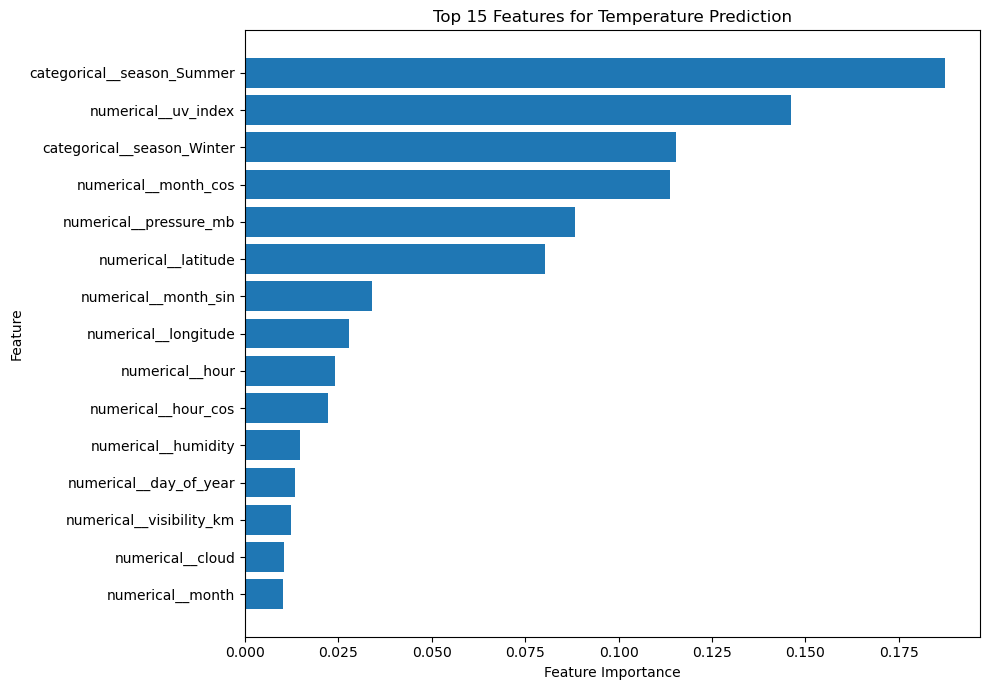

In [42]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================

top_features = (
    feature_importance_df
    .head(15)
    .sort_values(
        by='Importance'
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title(
    'Top 15 Features for Temperature Prediction'
)

plt.xlabel(
    'Feature Importance'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

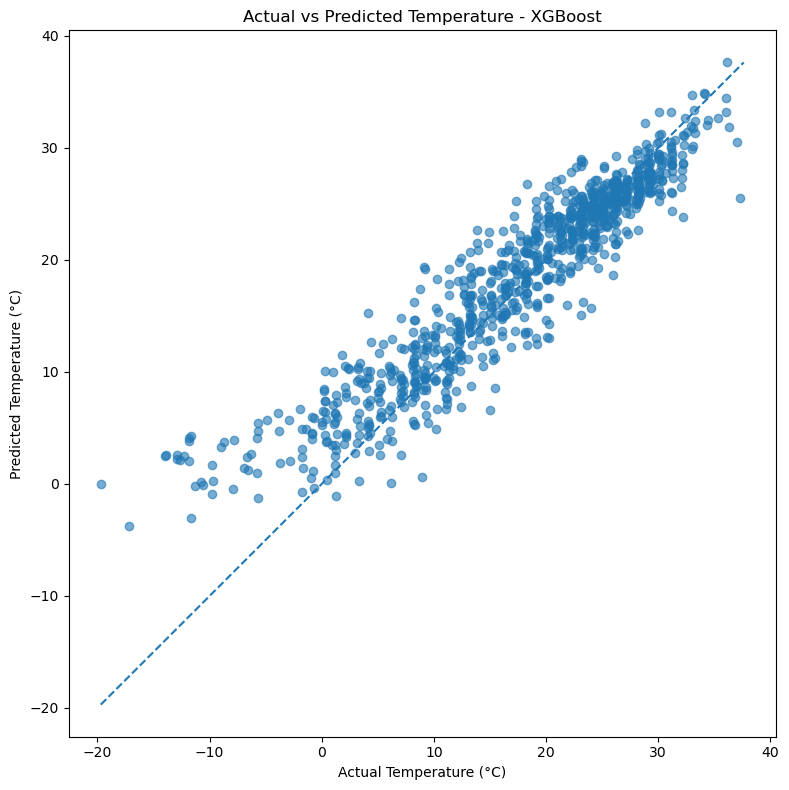

In [43]:
# ============================================
# ACTUAL VS PREDICTED TEMPERATURE
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_time,
    y_pred_xgb_tuned,
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    y_test_time.min(),
    y_pred_xgb_tuned.min()
)

max_value = max(
    y_test_time.max(),
    y_pred_xgb_tuned.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title(
    'Actual vs Predicted Temperature - XGBoost'
)

plt.xlabel(
    'Actual Temperature (°C)'
)

plt.ylabel(
    'Predicted Temperature (°C)'
)

plt.tight_layout()

plt.show()

In [44]:
# ============================================
# RESIDUAL ANALYSIS
# ============================================

residuals = (
    y_test_time
    - y_pred_xgb_tuned
)

print("=" * 60)
print("RESIDUAL STATISTICS")
print("=" * 60)

print(
    residuals.describe()
)

RESIDUAL STATISTICS
count    941.000000
mean      -1.036326
std        3.838031
min      -19.689150
25%       -2.935946
50%       -0.500340
75%        1.351007
max       11.805426
Name: temperature_celsius, dtype: float64


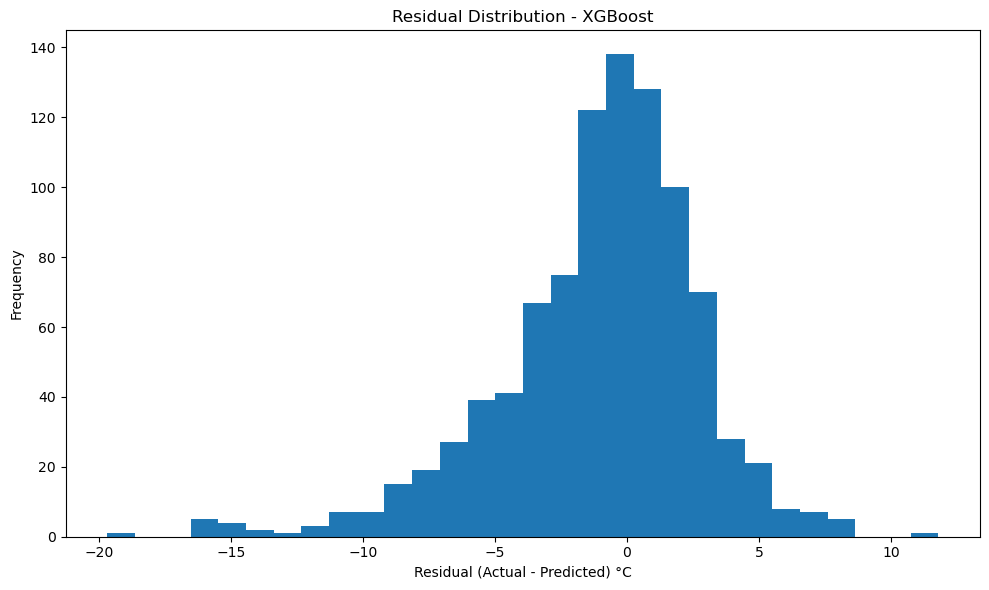

In [45]:
# ============================================
# RESIDUAL DISTRIBUTION
# ============================================

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    'Residual Distribution - XGBoost'
)

plt.xlabel(
    'Residual (Actual - Predicted) °C'
)

plt.ylabel(
    'Frequency'
)

plt.tight_layout()

plt.show()

In [46]:
# ============================================
# STEP 13: WORST PREDICTIONS - FIXED
# ============================================

# Get the original test data information
# using the same indices as the time-based test set

error_analysis = weather_df.loc[
    X_test_time.index,
    [
        'country',
        'location_name',
        'last_updated',
        'temperature_celsius'
    ]
].copy()

# Add predictions
error_analysis['predicted_temperature'] = (
    y_pred_xgb_tuned
)

# Calculate absolute error
error_analysis['absolute_error'] = (
    abs(
        error_analysis['temperature_celsius']
        - error_analysis['predicted_temperature']
    )
)

# Sort by largest error
error_analysis = (
    error_analysis
    .sort_values(
        by='absolute_error',
        ascending=False
    )
)

# Display top 20 worst predictions
print("=" * 60)
print("TOP 20 WORST PREDICTIONS")
print("=" * 60)

print(
    error_analysis.head(20)
)

TOP 20 WORST PREDICTIONS
                     country location_name        last_updated  \
3721                  Latvia          Riga 2026-02-01 09:00:00   
2613                  Canada        Ottawa 2026-02-07 01:45:00   
4924             Switzerland          Bern 2026-01-07 08:15:00   
3436               Lithuania       Vilnius 2026-01-13 09:30:00   
878                   Canada        Ottawa 2026-02-25 01:30:00   
23                  Slovenia     Ljubljana 2026-01-08 08:15:00   
256                   Russia        Moscow 2026-02-16 09:45:00   
3387                  Canada        Ottawa 2026-02-03 02:00:00   
3582                 Ukraine          Kyiv 2026-01-21 09:00:00   
2717                  Canada        Ottawa 2026-01-06 02:15:00   
4140                  Canada        Ottawa 2026-03-03 01:30:00   
40                   Ukraine          Kyiv 2026-02-21 08:45:00   
4266               Lithuania       Vilnius 2026-02-19 08:45:00   
35                    Sweden     Stockholm 2026-02-

In [47]:
# ============================================
# STEP 14: EXTREME TEMPERATURE ANALYSIS
# ============================================

print("=" * 60)
print("EXTREME TEMPERATURE ANALYSIS")
print("=" * 60)

# Extremely cold observations
cold_days = weather_df[
    weather_df['temperature_celsius'] <= 0
]

print("\nTemperature <= 0°C:")
print(f"Records: {len(cold_days)}")

# Very cold observations
very_cold_days = weather_df[
    weather_df['temperature_celsius'] <= -10
]

print("\nTemperature <= -10°C:")
print(f"Records: {len(very_cold_days)}")

# Extremely cold observations
extreme_cold_days = weather_df[
    weather_df['temperature_celsius'] <= -15
]

print("\nTemperature <= -15°C:")
print(f"Records: {len(extreme_cold_days)}")

# Warm observations
hot_days = weather_df[
    weather_df['temperature_celsius'] >= 35
]

print("\nTemperature >= 35°C:")
print(f"Records: {len(hot_days)}")

EXTREME TEMPERATURE ANALYSIS

Temperature <= 0°C:
Records: 135

Temperature <= -10°C:
Records: 24

Temperature <= -15°C:
Records: 5

Temperature >= 35°C:
Records: 160


In [48]:
# ============================================
# TEMPERATURE RANGE DISTRIBUTION
# ============================================

temperature_bins = pd.cut(
    weather_df['temperature_celsius'],
    bins=[
        -30,
        -15,
        -10,
        0,
        10,
        20,
        30,
        40,
        50
    ]
)

temperature_distribution = (
    temperature_bins
    .value_counts()
    .sort_index()
)

print(temperature_distribution)

temperature_celsius
(-30, -15]       5
(-15, -10]      19
(-10, 0]       111
(0, 10]        592
(10, 20]      1121
(20, 30]      2532
(30, 40]       587
(40, 50]        33
Name: count, dtype: int64


In [49]:
# ============================================
# COLD TEMPERATURES BY YEAR
# ============================================

cold_by_year = (
    weather_df[
        weather_df['temperature_celsius'] <= 0
    ]
    .groupby('year')
    .size()
)

print("Cold observations (<= 0°C) by year:")
print(cold_by_year)

print("\nVery cold observations (<= -10°C) by year:")

very_cold_by_year = (
    weather_df[
        weather_df['temperature_celsius'] <= -10
    ]
    .groupby('year')
    .size()
)

print(very_cold_by_year)

Cold observations (<= 0°C) by year:
year
2024    23
2025    57
2026    55
dtype: int64

Very cold observations (<= -10°C) by year:
year
2024     4
2025     4
2026    16
dtype: int64


In [50]:
# ============================================
# COLD VS NORMAL MODEL PERFORMANCE
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create evaluation DataFrame
evaluation_df = weather_df.loc[
    X_test_time.index,
    [
        'temperature_celsius'
    ]
].copy()

evaluation_df['predicted_temperature'] = (
    y_pred_xgb_tuned
)

# Cold temperatures
cold_mask = (
    evaluation_df['temperature_celsius'] <= 0
)

# Normal temperatures
normal_mask = (
    evaluation_df['temperature_celsius'] > 0
)

print("=" * 60)
print("COLD VS NORMAL PERFORMANCE")
print("=" * 60)

# Cold performance
cold_mae = mean_absolute_error(
    evaluation_df.loc[
        cold_mask,
        'temperature_celsius'
    ],
    evaluation_df.loc[
        cold_mask,
        'predicted_temperature'
    ]
)

print(
    f"\nCold MAE (<= 0°C): {cold_mae:.4f} °C"
)

# Normal performance
normal_mae = mean_absolute_error(
    evaluation_df.loc[
        normal_mask,
        'temperature_celsius'
    ],
    evaluation_df.loc[
        normal_mask,
        'predicted_temperature'
    ]
)

print(
    f"Normal MAE (> 0°C): {normal_mae:.4f} °C"
)

print(
    f"\nCold Records: {cold_mask.sum()}"
)

print(
    f"Normal Records: {normal_mask.sum()}"
)

COLD VS NORMAL PERFORMANCE

Cold MAE (<= 0°C): 9.2171 °C
Normal MAE (> 0°C): 2.4372 °C

Cold Records: 55
Normal Records: 886


In [51]:
# ============================================
# STEP 17: COLD-AWARE SAMPLE WEIGHTS
# ============================================

# Start with equal weight for all observations
sample_weights = np.ones(
    len(y_train_time)
)

# Increase importance of cold observations
sample_weights[
    y_train_time <= 0
] = 2.0

# Give additional weight to very cold observations
sample_weights[
    y_train_time <= -10
] = 3.0

print("=" * 60)
print("SAMPLE WEIGHT DISTRIBUTION")
print("=" * 60)

print("\nNormal (> 0°C):")
print(
    (sample_weights == 1.0).sum()
)

print("\nCold (<= 0°C):")
print(
    (sample_weights == 2.0).sum()
)

print("\nVery Cold (<= -10°C):")
print(
    (sample_weights == 3.0).sum()
)

SAMPLE WEIGHT DISTRIBUTION

Normal (> 0°C):
3979

Cold (<= 0°C):
72

Very Cold (<= -10°C):
8


In [52]:
# ============================================
# COLD-AWARE XGBOOST
# ============================================

cold_aware_xgb = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),
        (
            'model',
            XGBRegressor(
                n_estimators=700,
                learning_rate=0.1,
                max_depth=5,
                min_child_weight=5,
                subsample=0.7,
                colsample_bytree=0.7,
                random_state=42,
                objective='reg:squarederror',
                n_jobs=-1
            )
        )
    ]
)

print("Cold-aware XGBoost pipeline created.")

Cold-aware XGBoost pipeline created.


In [53]:
# ============================================
# TRAIN COLD-AWARE XGBOOST
# ============================================

cold_aware_xgb.fit(
    X_train_time,
    y_train_time,
    model__sample_weight=sample_weights
)

print("Cold-aware XGBoost trained successfully.")

Cold-aware XGBoost trained successfully.


In [54]:
# ============================================
# COLD-AWARE PREDICTIONS
# ============================================

y_pred_cold_aware = (
    cold_aware_xgb
    .predict(X_test_time)
)

print("Predictions generated successfully.")

Predictions generated successfully.


In [55]:
# ============================================
# COLD-AWARE OVERALL EVALUATION
# ============================================

mae_cold_aware = mean_absolute_error(
    y_test_time,
    y_pred_cold_aware
)

rmse_cold_aware = np.sqrt(
    mean_squared_error(
        y_test_time,
        y_pred_cold_aware
    )
)

r2_cold_aware = r2_score(
    y_test_time,
    y_pred_cold_aware
)

print("=" * 60)
print("COLD-AWARE XGBOOST - 2026 EVALUATION")
print("=" * 60)

print(
    f"\nMAE  : {mae_cold_aware:.4f} °C"
)

print(
    f"RMSE : {rmse_cold_aware:.4f} °C"
)

print(
    f"R²   : {r2_cold_aware:.4f}"
)

COLD-AWARE XGBOOST - 2026 EVALUATION

MAE  : 2.7902 °C
RMSE : 3.9332 °C
R²   : 0.8567


In [56]:
# ============================================
# COLD-AWARE: COLD VS NORMAL PERFORMANCE
# ============================================

cold_aware_eval = weather_df.loc[
    X_test_time.index,
    [
        'temperature_celsius'
    ]
].copy()

cold_aware_eval[
    'predicted_temperature'
] = y_pred_cold_aware

# Masks
cold_mask = (
    cold_aware_eval[
        'temperature_celsius'
    ] <= 0
)

normal_mask = (
    cold_aware_eval[
        'temperature_celsius'
    ] > 0
)

# Cold MAE
cold_mae_new = mean_absolute_error(
    cold_aware_eval.loc[
        cold_mask,
        'temperature_celsius'
    ],
    cold_aware_eval.loc[
        cold_mask,
        'predicted_temperature'
    ]
)

# Normal MAE
normal_mae_new = mean_absolute_error(
    cold_aware_eval.loc[
        normal_mask,
        'temperature_celsius'
    ],
    cold_aware_eval.loc[
        normal_mask,
        'predicted_temperature'
    ]
)

print("=" * 60)
print("COLD-AWARE MODEL PERFORMANCE")
print("=" * 60)

print(
    f"\nCold MAE (<= 0°C): "
    f"{cold_mae_new:.4f} °C"
)

print(
    f"Normal MAE (> 0°C): "
    f"{normal_mae_new:.4f} °C"
)

COLD-AWARE MODEL PERFORMANCE

Cold MAE (<= 0°C): 8.8105 °C
Normal MAE (> 0°C): 2.4165 °C


In [57]:
# ============================================
# STEP 18: FINAL MODEL COMPARISON
# ============================================

final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost Baseline',
        'Tuned XGBoost',
        'Cold-Aware XGBoost'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_xgb_tuned,
        mae_cold_aware
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_xgb_tuned,
        rmse_cold_aware
    ],
    'R2': [
        r2_lr,
        r2_rf,
        r2_xgb,
        r2_xgb_tuned,
        r2_cold_aware
    ]
})

# Sort by R²
final_results = (
    final_results
    .sort_values(
        by='R2',
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(final_results.to_string(index=False))

FINAL MODEL COMPARISON
             Model      MAE     RMSE       R2
Cold-Aware XGBoost 2.790232 3.933191 0.856685
     Tuned XGBoost 2.833448 3.973512 0.853732
  XGBoost Baseline 2.869500 4.064776 0.846936
     Random Forest 3.040700 4.294647 0.829134
 Linear Regression 5.746025 7.560663 0.470434


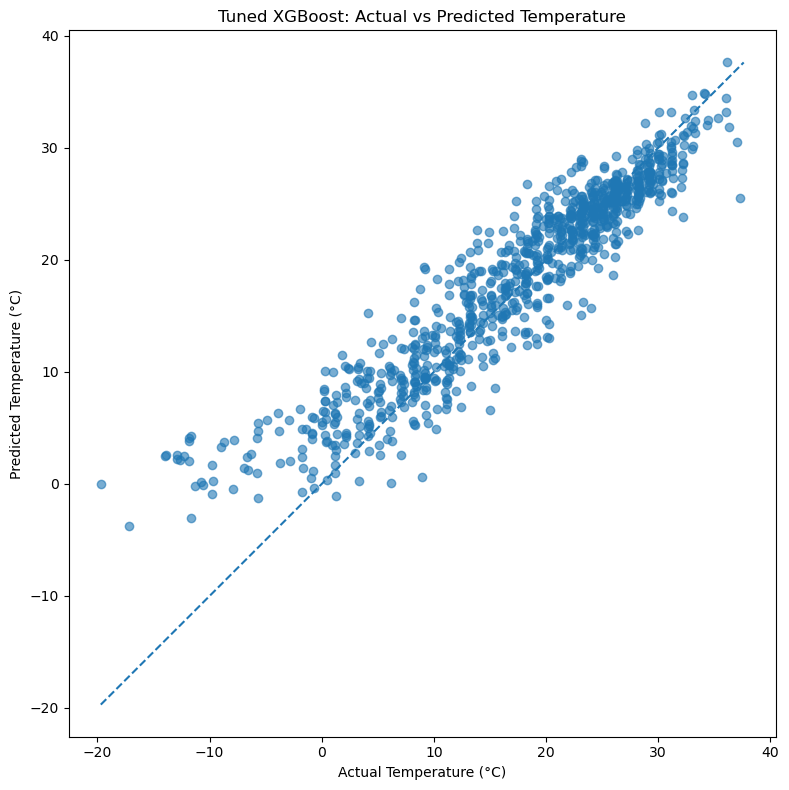

In [58]:
# ============================================
# STEP 19: FINAL MODEL - ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_time,
    y_pred_xgb_tuned,
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    y_test_time.min(),
    y_pred_xgb_tuned.min()
)

max_value = max(
    y_test_time.max(),
    y_pred_xgb_tuned.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.title(
    'Tuned XGBoost: Actual vs Predicted Temperature'
)

plt.xlabel(
    'Actual Temperature (°C)'
)

plt.ylabel(
    'Predicted Temperature (°C)'
)

plt.tight_layout()

plt.show()

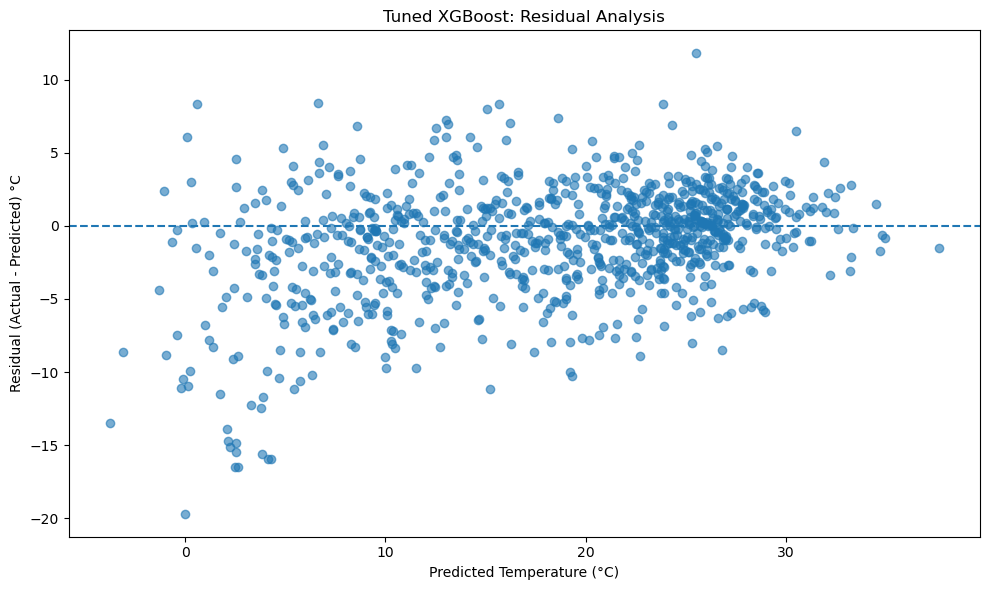

In [59]:
# ============================================
# STEP 20: FINAL RESIDUAL ANALYSIS
# ============================================

final_residuals = (
    y_test_time
    - y_pred_xgb_tuned
)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_xgb_tuned,
    final_residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(
    'Tuned XGBoost: Residual Analysis'
)

plt.xlabel(
    'Predicted Temperature (°C)'
)

plt.ylabel(
    'Residual (Actual - Predicted) °C'
)

plt.tight_layout()

plt.show()

In [60]:
# ============================================
# STEP 21: FINAL PREDICTION EXAMPLES
# ============================================

final_predictions = weather_df.loc[
    X_test_time.index,
    [
        'country',
        'location_name',
        'last_updated',
        'temperature_celsius'
    ]
].copy()

final_predictions[
    'predicted_temperature'
] = y_pred_xgb_tuned

final_predictions[
    'absolute_error'
] = abs(
    final_predictions[
        'temperature_celsius'
    ]
    -
    final_predictions[
        'predicted_temperature'
    ]
)

print("=" * 80)
print("SAMPLE FINAL PREDICTIONS")
print("=" * 80)

print(
    final_predictions.head(20).to_string(
        index=False
    )
)

SAMPLE FINAL PREDICTIONS
          country       location_name        last_updated  temperature_celsius  predicted_temperature  absolute_error
         Bulgaria                 Lom 2026-02-13 10:00:00                  1.4               5.982557        4.582557
       Cape Verde               Praia 2026-04-08 05:30:00                 21.0              22.955732        1.955732
          Romania           Bucharest 2026-01-23 09:15:00                  1.2               3.494115        2.294115
          Uruguay          Montevideo 2026-01-16 04:15:00                 22.1              18.832144        3.267856
Brunei Darussalam Bandar Seri Begawan 2026-01-26 15:00:00                 30.3              28.888350        1.411650
         Slovenia           Ljubljana 2026-01-08 08:15:00                -11.8               3.820231       15.620231
           Sweden           Stockholm 2026-02-06 07:45:00                 -9.0               3.275523       12.275523
          Ukraine              

In [64]:
[name for name in globals() if 'xgb' in name.lower()]

['XGBRegressor',
 'xgboost_pipeline',
 'y_pred_xgb',
 'mae_xgb',
 'rmse_xgb',
 'r2_xgb',
 'xgb_tuning_pipeline',
 'best_xgb_model',
 'y_pred_xgb_tuned',
 'mae_xgb_tuned',
 'rmse_xgb_tuned',
 'r2_xgb_tuned',
 'fitted_xgb',
 'cold_aware_xgb']

NameError: name 'ACTUAL_VARIABLE_NAME' is not defined

In [65]:
# ============================================
# STEP 22: SAVE FINAL TUNED XGBOOST MODEL
# ============================================

import joblib

# Save the final tuned XGBoost pipeline
joblib.dump(
    best_xgb_model,
    'weather_temperature_forecaster.pkl'
)

print("=" * 60)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 60)

print("\nModel: Tuned XGBoost")
print("File: weather_temperature_forecaster.pkl")

FINAL MODEL SAVED SUCCESSFULLY

Model: Tuned XGBoost
File: weather_temperature_forecaster.pkl


In [66]:
# ============================================
# STEP 23: LOAD AND VERIFY FINAL MODEL
# ============================================

import joblib

# Load saved model
loaded_model = joblib.load(
    'weather_temperature_forecaster.pkl'
)

print("=" * 60)
print("MODEL LOADED SUCCESSFULLY")
print("=" * 60)

print("\nModel Type:")
print(type(loaded_model))

print("\nModel:")
print(loaded_model)

MODEL LOADED SUCCESSFULLY

Model Type:
<class 'sklearn.pipeline.Pipeline'>

Model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'wind_kph', 'wind_degree',
                                                   'pressure_mb', 'precip_mm',
                                                   'humidity', 'cloud',
                                                   'visibility_km', 'uv_index',
                                                   'gust_kph',
                                                   'air_quality_Carbon_Monoxide',
                                                   'air_quality_Ozone',
                                                   'air_quality_Nitrogen_dioxide',
                                                   'air_quality_Sulphur_dioxide',
                                    

In [67]:
# ============================================
# STEP 24: CREATE PREDICTION FUNCTION
# ============================================

def predict_temperature(input_data):
    """
    Predict temperature using the trained
    Tuned XGBoost weather forecasting model.
    """

    # Make prediction
    prediction = loaded_model.predict(
        input_data
    )

    # Return first prediction
    return prediction[0]


print("Prediction function created successfully.")

Prediction function created successfully.


In [68]:
# ============================================
# STEP 25: TEST PREDICTION FUNCTION
# ============================================

# Take one observation from test data
sample_input = X_test_time.iloc[[0]].copy()

# Actual temperature
actual_temperature = y_test_time.iloc[0]

# Predict temperature
predicted_temperature = predict_temperature(
    sample_input
)

print("=" * 60)
print("SAMPLE TEMPERATURE PREDICTION")
print("=" * 60)

print(
    f"\nActual Temperature    : "
    f"{actual_temperature:.2f} °C"
)

print(
    f"Predicted Temperature : "
    f"{predicted_temperature:.2f} °C"
)

print(
    f"Absolute Error        : "
    f"{abs(actual_temperature - predicted_temperature):.2f} °C"
)

SAMPLE TEMPERATURE PREDICTION

Actual Temperature    : 1.40 °C
Predicted Temperature : 5.98 °C
Absolute Error        : 4.58 °C


In [71]:
# ============================================
# STEP 26A: PRODUCTION PREDICTION FUNCTION
# ============================================

import pandas as pd
import numpy as np


def create_prediction_input(
    latitude,
    longitude,
    wind_kph,
    wind_degree,
    pressure_mb,
    precip_mm,
    humidity,
    cloud,
    visibility_km,
    uv_index,
    gust_kph,
    air_quality_Carbon_Monoxide,
    air_quality_Ozone,
    air_quality_Nitrogen_dioxide,
    air_quality_Sulphur_dioxide,
    air_quality_PM2_5,
    air_quality_PM10,
    air_quality_us_epa_index,
    air_quality_gb_defra_index,
    moon_illumination,
    date_time
):
    
    # Convert input date/time
    date_time = pd.to_datetime(date_time)

    # Time-based features
    year = date_time.year
    month = date_time.month
    day = date_time.day
    hour = date_time.hour
    day_of_year = date_time.dayofyear
    day_of_week = date_time.dayofweek

    # Season
    if month in [12, 1, 2]:
        season = "Winter"
    elif month in [3, 4, 5]:
        season = "Spring"
    elif month in [6, 7, 8]:
        season = "Summer"
    else:
        season = "Autumn"

    # Cyclical features
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    # Create input DataFrame
    input_data = pd.DataFrame([{
        'latitude': latitude,
        'longitude': longitude,
        'wind_kph': wind_kph,
        'wind_degree': wind_degree,
        'pressure_mb': pressure_mb,
        'precip_mm': precip_mm,
        'humidity': humidity,
        'cloud': cloud,
        'visibility_km': visibility_km,
        'uv_index': uv_index,
        'gust_kph': gust_kph,

        'air_quality_Carbon_Monoxide':
            air_quality_Carbon_Monoxide,

        'air_quality_Ozone':
            air_quality_Ozone,

        'air_quality_Nitrogen_dioxide':
            air_quality_Nitrogen_dioxide,

        'air_quality_Sulphur_dioxide':
            air_quality_Sulphur_dioxide,

        'air_quality_PM2.5':
            air_quality_PM2_5,

        'air_quality_PM10':
            air_quality_PM10,

        'air_quality_us-epa-index':
            air_quality_us_epa_index,

        'air_quality_gb-defra-index':
            air_quality_gb_defra_index,

        'moon_illumination':
            moon_illumination,

        'year': year,
        'month': month,
        'day': day,
        'hour': hour,
        'day_of_year': day_of_year,
        'day_of_week': day_of_week,

        'season': season,

        'month_sin': month_sin,
        'month_cos': month_cos,

        'hour_sin': hour_sin,
        'hour_cos': hour_cos
    }])

    return input_data

In [72]:
# ============================================
# STEP 26B: FINAL TEMPERATURE PREDICTION
# ============================================

def predict_temperature_from_raw_input(
    latitude,
    longitude,
    wind_kph,
    wind_degree,
    pressure_mb,
    precip_mm,
    humidity,
    cloud,
    visibility_km,
    uv_index,
    gust_kph,
    air_quality_Carbon_Monoxide,
    air_quality_Ozone,
    air_quality_Nitrogen_dioxide,
    air_quality_Sulphur_dioxide,
    air_quality_PM2_5,
    air_quality_PM10,
    air_quality_us_epa_index,
    air_quality_gb_defra_index,
    moon_illumination,
    date_time
):

    # Create model-ready features
    input_data = create_prediction_input(
        latitude=latitude,
        longitude=longitude,
        wind_kph=wind_kph,
        wind_degree=wind_degree,
        pressure_mb=pressure_mb,
        precip_mm=precip_mm,
        humidity=humidity,
        cloud=cloud,
        visibility_km=visibility_km,
        uv_index=uv_index,
        gust_kph=gust_kph,
        air_quality_Carbon_Monoxide=
            air_quality_Carbon_Monoxide,
        air_quality_Ozone=
            air_quality_Ozone,
        air_quality_Nitrogen_dioxide=
            air_quality_Nitrogen_dioxide,
        air_quality_Sulphur_dioxide=
            air_quality_Sulphur_dioxide,
        air_quality_PM2_5=
            air_quality_PM2_5,
        air_quality_PM10=
            air_quality_PM10,
        air_quality_us_epa_index=
            air_quality_us_epa_index,
        air_quality_gb_defra_index=
            air_quality_gb_defra_index,
        moon_illumination=
            moon_illumination,
        date_time=date_time
    )

    # Predict using saved final pipeline
    prediction = loaded_model.predict(
        input_data
    )

    return prediction[0]

In [73]:
# ============================================
# STEP 26C: TEST PRODUCTION PREDICTION
# ============================================

prediction = predict_temperature_from_raw_input(

    latitude=23.0225,
    longitude=72.5714,

    wind_kph=12.0,
    wind_degree=180,

    pressure_mb=1008.0,
    precip_mm=0.0,

    humidity=60,
    cloud=20,

    visibility_km=10.0,

    uv_index=7.0,

    gust_kph=18.0,

    air_quality_Carbon_Monoxide=200.0,
    air_quality_Ozone=80.0,
    air_quality_Nitrogen_dioxide=20.0,
    air_quality_Sulphur_dioxide=5.0,

    air_quality_PM2_5=30.0,
    air_quality_PM10=50.0,

    air_quality_us_epa_index=2,
    air_quality_gb_defra_index=2,

    moon_illumination=50,

    date_time="2026-07-25 12:00:00"
)

print("=" * 60)
print("FINAL WEATHER TEMPERATURE FORECAST")
print("=" * 60)

print(
    f"Predicted Temperature: "
    f"{prediction:.2f} °C"
)

FINAL WEATHER TEMPERATURE FORECAST
Predicted Temperature: 32.15 °C


In [75]:
import sys

print(sys.executable)

C:\Users\KEYUR\anaconda3\python.exe


In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [ ]:
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

In [ ]:
df.info()

# Exploratory Data Analysis (EDA)

This section explores weather trends, precipitation patterns, environmental conditions, and correlations between weather variables.

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['temperature_celsius'],
    kde=True,
    bins=30
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.savefig("../images/temperature_distribution.png")

plt.show()

In [ ]:
top_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_temp.plot(kind='bar')

plt.title("Top 10 Hottest Countries")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.savefig("../images/hottest_countries.png")

plt.show()

In [ ]:
cold_temp = (
    df.groupby('country')['temperature_celsius']
    .mean()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(12,6))

cold_temp.plot(kind='bar')

plt.title("Top 10 Coldest Countries")
plt.ylabel("Average Temperature (°C)")
plt.xticks(rotation=45)
plt.savefig("../images/coldest_countries.png")

plt.show()

In [ ]:
monthly_temp = (
    df.groupby('month')['temperature_celsius']
    .mean()
)

plt.figure(figsize=(10,5))

monthly_temp.plot(
    marker='o',
    linewidth=2
)

plt.title("Monthly Average Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.savefig("../images/monthly_trend.png")


plt.show()

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['precip_mm'],
    bins=30
)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.savefig("../images/precipitation.png")


plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='humidity',
    y='temperature_celsius',
    data=df
)

plt.title("Humidity vs Temperature")
plt.savefig("../images/humidity_vs_temperature.png")


plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='air_quality_PM2.5',
    y='temperature_celsius',
    data=df
)

plt.title("PM2.5 vs Temperature")
plt.savefig("../images/PM2.5_vs_temperature.png")


plt.show()

In [ ]:
plt.figure(figsize=(18,12))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")


plt.show()

# Forecasting Models

This section builds and compares multiple machine learning models to forecast weather trends.

In [ ]:
features = [
    'humidity',
    'wind_kph',
    'pressure_mb',
    'precip_mm',
    'air_quality_PM2.5',
    'cloud',
    'feels_like_celsius'
]

X = df[features]

y = df['temperature_celsius']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
print("Linear Regression Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score:", r2_score(y_test, lr_pred))

To balance computational efficiency and model performance, Random Forest hyperparameters were optimized using limited tree depth and reduced estimators.

In [ ]:
import time

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print("Training Time:", end - start)

rf_pred = rf.predict(X_test)

In [ ]:
print("Random Forest Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:", r2_score(y_test, rf_pred))

In [ ]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
print("XGBoost Results")
print("-" * 40)

print("MAE:", mean_absolute_error(y_test, xgb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 Score:", r2_score(y_test, xgb_pred))

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],

    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],

    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison - R2 Score")
plt.savefig("../images/model_comparison.png")

plt.show()

# Feature Importance Analysis

This section identifies the most influential features affecting temperature prediction.

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
)

importance = importance.sort_values()

In [ ]:
plt.figure(figsize=(10,6))

importance.plot(kind='barh')

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.savefig("../images/feature_importance.png")

plt.show()

# Anomaly Detection

Isolation Forest is used to detect unusual weather patterns and extreme temperature observations.

In [ ]:
iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

df['anomaly'] = iso.fit_predict(
    df[['temperature_celsius']]
)

In [ ]:
df['anomaly'].value_counts()

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df.index,
    y='temperature_celsius',
    hue='anomaly',
    data=df
)

plt.title("Temperature Anomaly Detection")

plt.xlabel("Data Index")

plt.ylabel("Temperature (°C)")

plt.savefig("../images/anomaly_detection.png")

plt.show()

# Climate Pattern Analysis

This section analyzes long-term temperature patterns across countries and regions.

In [ ]:
humid = (
    df.groupby('country')['humidity']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

humid.plot(kind='bar')

plt.title("Top 10 Most Humid Countries")

plt.ylabel("Average Humidity")

plt.savefig("../images/humidity_analysis.png")

plt.show()

In [ ]:
aqi = (
    df.groupby('country')['air_quality_PM2.5']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

aqi.plot(kind='bar')

plt.title("Countries with Highest PM2.5 Levels")

plt.ylabel("PM2.5")

plt.savefig("../images/aqi_analysis.png")

plt.show()

In [ ]:
plt.figure(figsize=(12,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['temperature_celsius'],
    cmap='coolwarm',
    alpha=0.5
)

plt.colorbar(label='Temperature (°C)')

plt.title("Global Temperature Distribution")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig("../images/spatial_analysis.png")

plt.show()

# Key Insights

## Major Findings

- Random Forest achieved the best forecasting performance.
- Temperature showed strong relationships with humidity, cloud cover, and feels-like temperature.
- Air quality indicators demonstrated environmental correlations with weather conditions.
- Several anomalous weather observations were detected using Isolation Forest.
- Spatial analysis revealed geographical temperature variations across regions.

In [ ]:
df.sample(5000).to_csv(
    "../data/sample_weather_data.csv",
    index=False
)